# 05 — Detailed Exploratory Data Analysis

A thorough EDA of the cleaned heart-failure data, organized around the topics we covered in **Chapters 1–5**. Every figure and table is saved under `reports/` for the write-up.

| Section | Chapter |
|---|---|
| Variables and data types | 1.1–1.3 |
| Univariate descriptive statistics | 1.4 |
| Probability distributions (normal, gamma, z-scores) | 2 |
| Sampling distribution of the mean / CLT | 3 |
| Confidence intervals, bootstrap, Bayesian proportion | 4 |
| Correlation, regression line, and significance tests | 1.5, 5 |

**Input**: `data/processed/cleaned.csv`  
**Outputs**: `reports/figures/*.png`, `reports/tables/*.csv`

In [1]:
# add the project folder to the path so we can import our own code in src/
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from src.config import PROCESSED_DIR, REPORTS_DIR, FIGURES_DIR, TARGET

sns.set_theme()

# where we save the report artifacts
TABLES_DIR = REPORTS_DIR / 'tables'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

# small helpers so every result gets written to disk as we go
def save_fig(fig, name):
    fig.savefig(FIGURES_DIR / name, dpi=120, bbox_inches='tight')
    print('saved figure:', name)

def save_table(frame, name):
    frame.to_csv(TABLES_DIR / name)
    print('saved table :', name)

df = pd.read_csv(PROCESSED_DIR / 'cleaned.csv')
print('rows:', len(df), '| columns:', df.shape[1])

# group the columns by type once, reused throughout
numeric = ['age', 'bmi', 'bnp', 'sodium', 'creatinine',
           'systolic_bp', 'heart_rate', 'adherence_score', 'distance_to_hospital_km']
binary = ['ace_inhibitor', 'beta_blocker', 'diuretic']
categorical = ['gender', 'income_level']
df.head()

rows: 3000 | columns: 15


,age,gender,bmi,bnp,sodium,creatinine,systolic_bp,heart_rate,ace_inhibitor,beta_blocker,diuretic,adherence_score,income_level,distance_to_hospital_km,readmitted_30d
0,76.0,Male,23.9,738.0,135.3,1.58,151.0,93.0,1,1,0,0.98,Medium,12.4,0
1,77.0,Male,32.3,405.0,143.0,1.50,107.0,74.0,1,0,1,0.66,Medium,38.8,1
2,42.0,Male,29.3,399.0,NaN,1.43,121.0,97.0,1,0,1,0.93,Low,43.5,1
3,83.0,Female,29.1,524.0,135.1,0.91,114.0,66.0,0,1,1,0.54,Low,33.3,1
4,48.0,Female,24.2,301.0,139.5,0.54,122.0,79.0,1,1,1,0.78,High,21.3,0


## 1. Variables and data types (Ch 1.1–1.3)

Before summarizing anything, classify each column: is it quantitative or categorical, and is it the response or an explanatory variable? This is observational data, so any association we find is **not** evidence of causation (Ch 1.3).

In [3]:
# classify every variable by type and role (response vs explanatory)
roles = []
for col in df.columns:
    if col == TARGET:
        roles.append((col, 'categorical (binary)', 'response'))
    elif col in numeric:
        roles.append((col, 'quantitative (continuous)', 'explanatory'))
    elif col in binary:
        roles.append((col, 'categorical (binary 0/1)', 'explanatory'))
    else:
        roles.append((col, 'categorical', 'explanatory'))
var_types = pd.DataFrame(roles, columns=['variable', 'type', 'role']).set_index('variable')
save_table(var_types, 'tbl_variable_types.csv')
var_types

saved table : tbl_variable_types.csv


,type,role
variable,,
age,quantitative (continuous),explanatory
gender,categorical,explanatory
bmi,quantitative (continuous),explanatory
bnp,quantitative (continuous),explanatory
sodium,quantitative (continuous),explanatory
creatinine,quantitative (continuous),explanatory
systolic_bp,quantitative (continuous),explanatory
heart_rate,quantitative (continuous),explanatory
ace_inhibitor,categorical (binary 0/1),explanatory


## 2. Univariate descriptive statistics (Ch 1.4)

Center (mean/median), spread (standard deviation, variance, IQR), position (quartiles), and shape (skewness). Histograms show the distribution shape; box plots show position and outliers.

In [4]:
# full numeric summary: the 5-number summary plus mean, std, variance and skewness
summary = df[numeric].describe().T  # count, mean, std, min, quartiles, max
summary['variance'] = df[numeric].var()
summary['skewness'] = df[numeric].skew()  # >0 right-skewed, <0 left-skewed
summary = summary.round(3)
save_table(summary, 'tbl_numeric_summary.csv')
summary

saved table : tbl_numeric_summary.csv


,count,mean,std,min,25%,50%,75%,max,variance,skewness
age,3000.0,65.254,14.806,40.0,52.00,65.00,78.000,90.00,219.231,-0.034
bmi,2909.0,28.116,4.937,11.5,24.80,28.10,31.500,44.90,24.373,-0.037
bnp,3000.0,406.308,232.273,50.0,225.00,392.00,569.000,1381.00,53950.793,0.346
sodium,2910.0,138.089,4.032,124.7,135.30,138.10,140.800,151.60,16.256,0.036
creatinine,2892.0,1.204,0.479,0.0,0.87,1.20,1.520,2.94,0.230,0.134
systolic_bp,3000.0,129.589,20.257,61.0,116.00,130.00,143.000,196.00,410.351,-0.104
heart_rate,2998.0,79.402,15.203,34.0,69.00,79.00,90.000,147.00,231.145,0.003
adherence_score,3000.0,0.699,0.173,0.4,0.55,0.70,0.850,1.00,0.030,0.023
distance_to_hospital_km,3000.0,25.400,14.146,1.0,12.80,25.45,37.525,50.00,200.102,0.004


saved figure: fig_hist_numeric.png


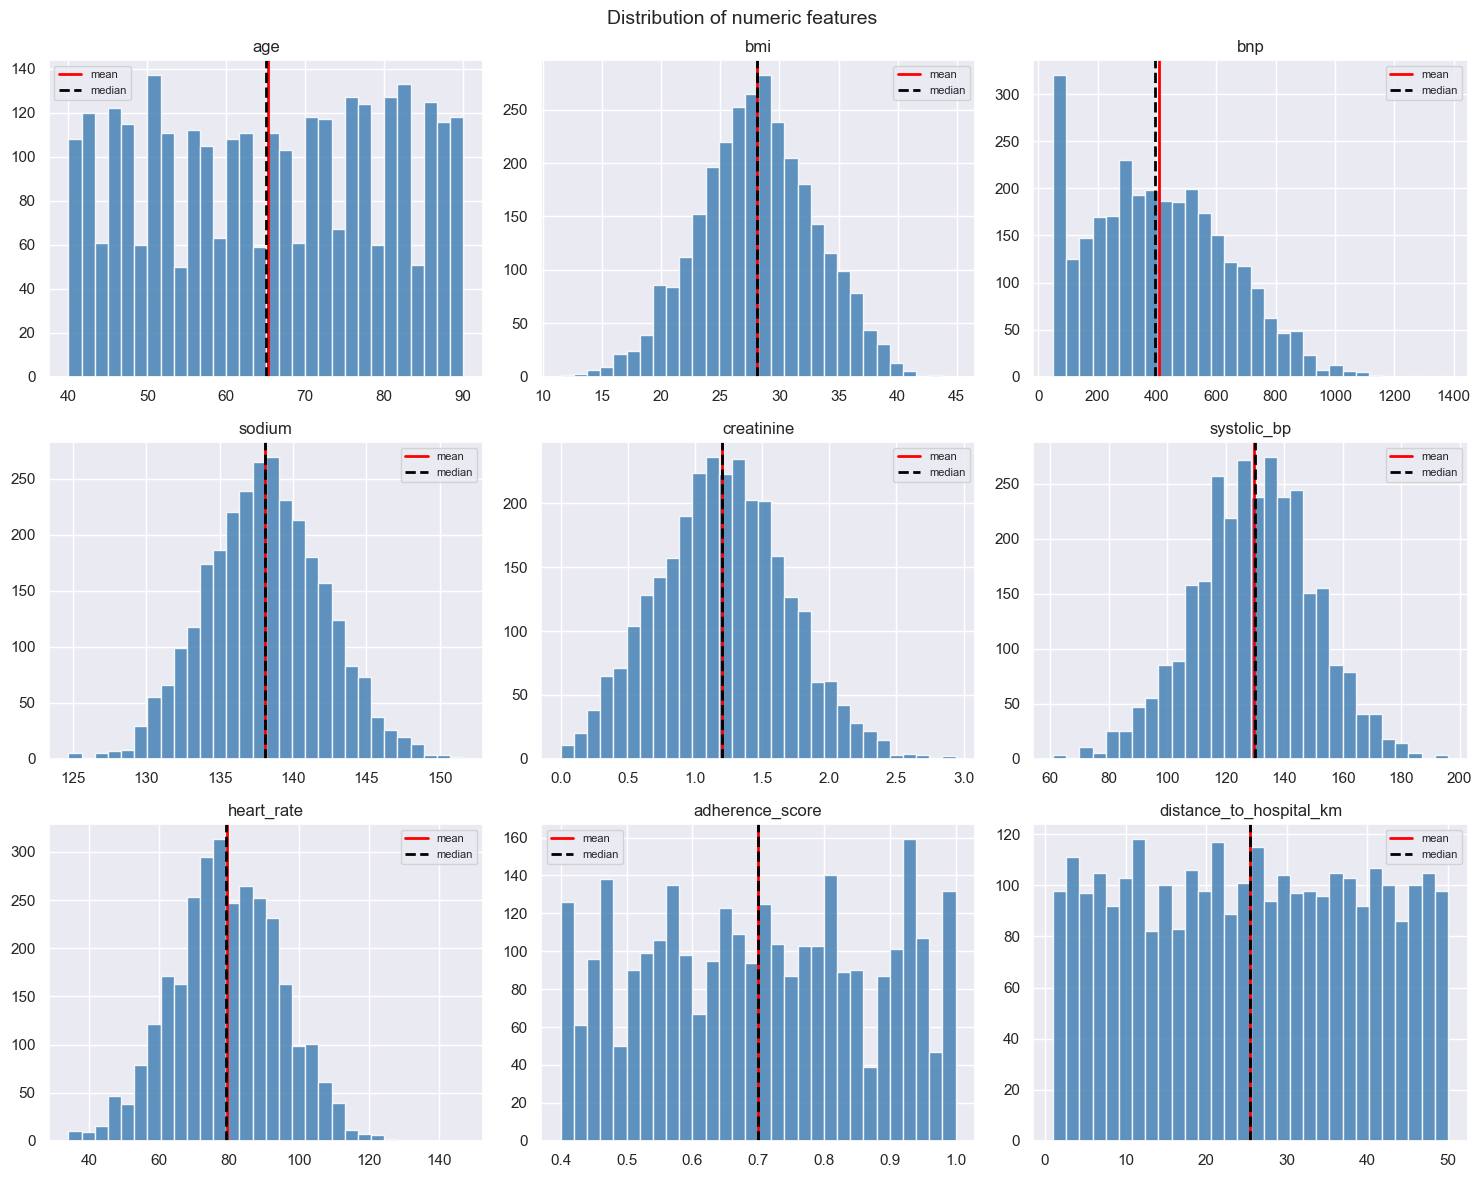

In [5]:
# histogram of every numeric feature, with mean (solid) and median (dashed) marked
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for ax, col in zip(axes.ravel(), numeric):
    ax.hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(df[col].mean(), color='red', linewidth=2, label='mean')
    ax.axvline(df[col].median(), color='black', linestyle='dashed', linewidth=2, label='median')
    ax.set_title(col)
    ax.legend(fontsize=8)
fig.suptitle('Distribution of numeric features', fontsize=14)
fig.tight_layout()
save_fig(fig, 'fig_hist_numeric.png')
plt.show()

saved figure: fig_box_numeric.png


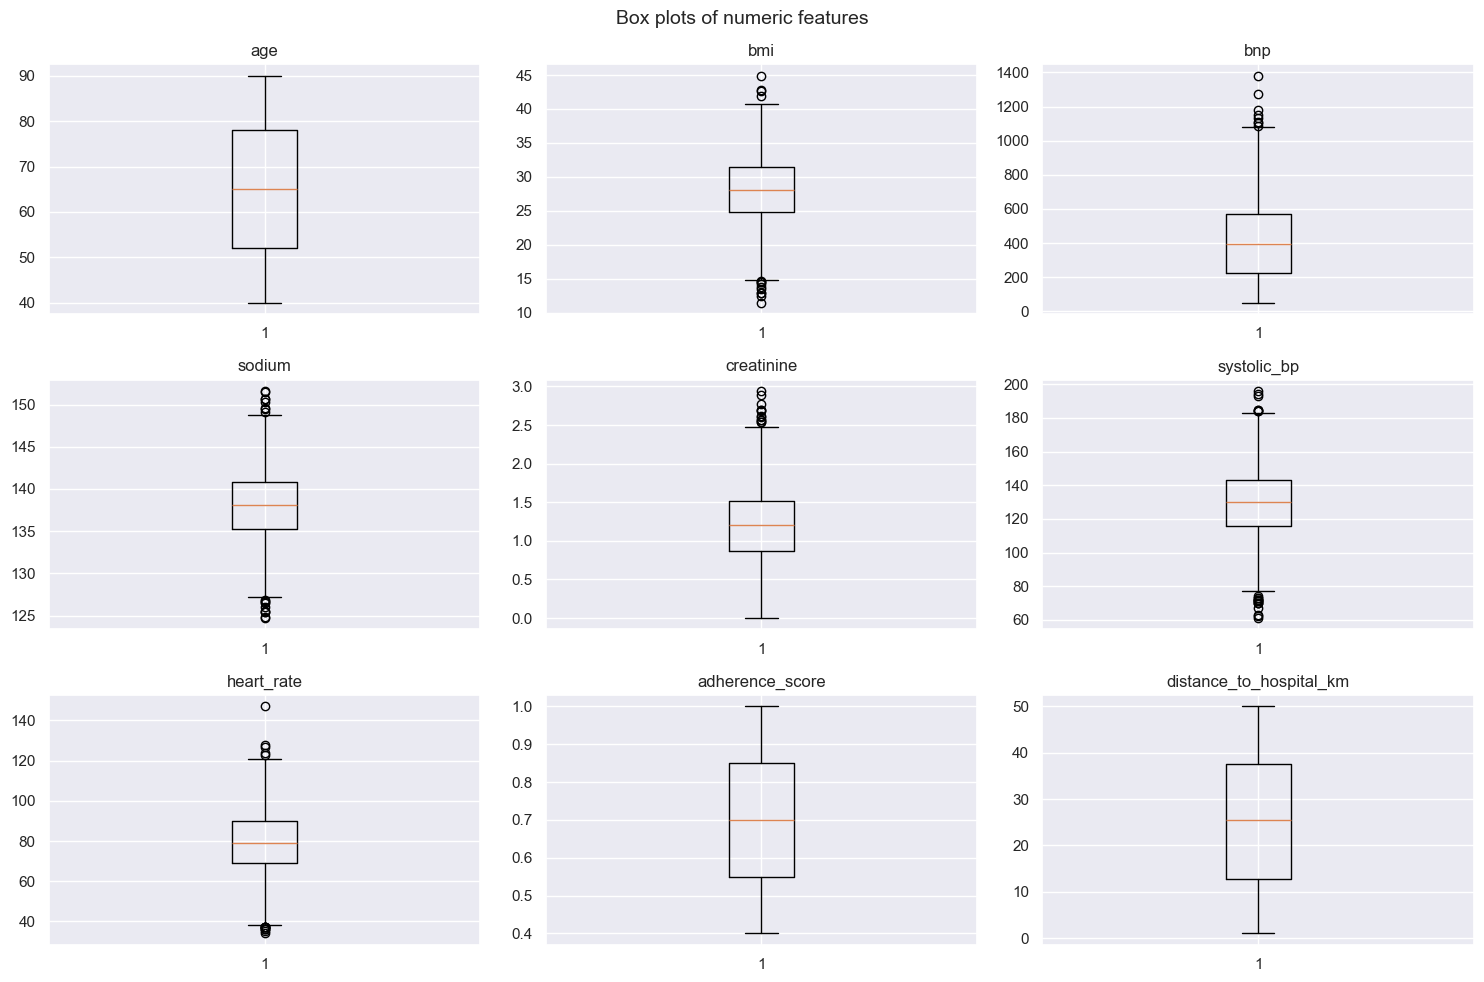

In [6]:
# box plots show the median, IQR and any 1.5*IQR outliers (Ch 1.4 - describing position)
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for ax, col in zip(axes.ravel(), numeric):
    ax.boxplot(df[col].dropna(), vert=True)
    ax.set_title(col)
fig.suptitle('Box plots of numeric features', fontsize=14)
fig.tight_layout()
save_fig(fig, 'fig_box_numeric.png')
plt.show()

saved figure: fig_bar_categorical.png


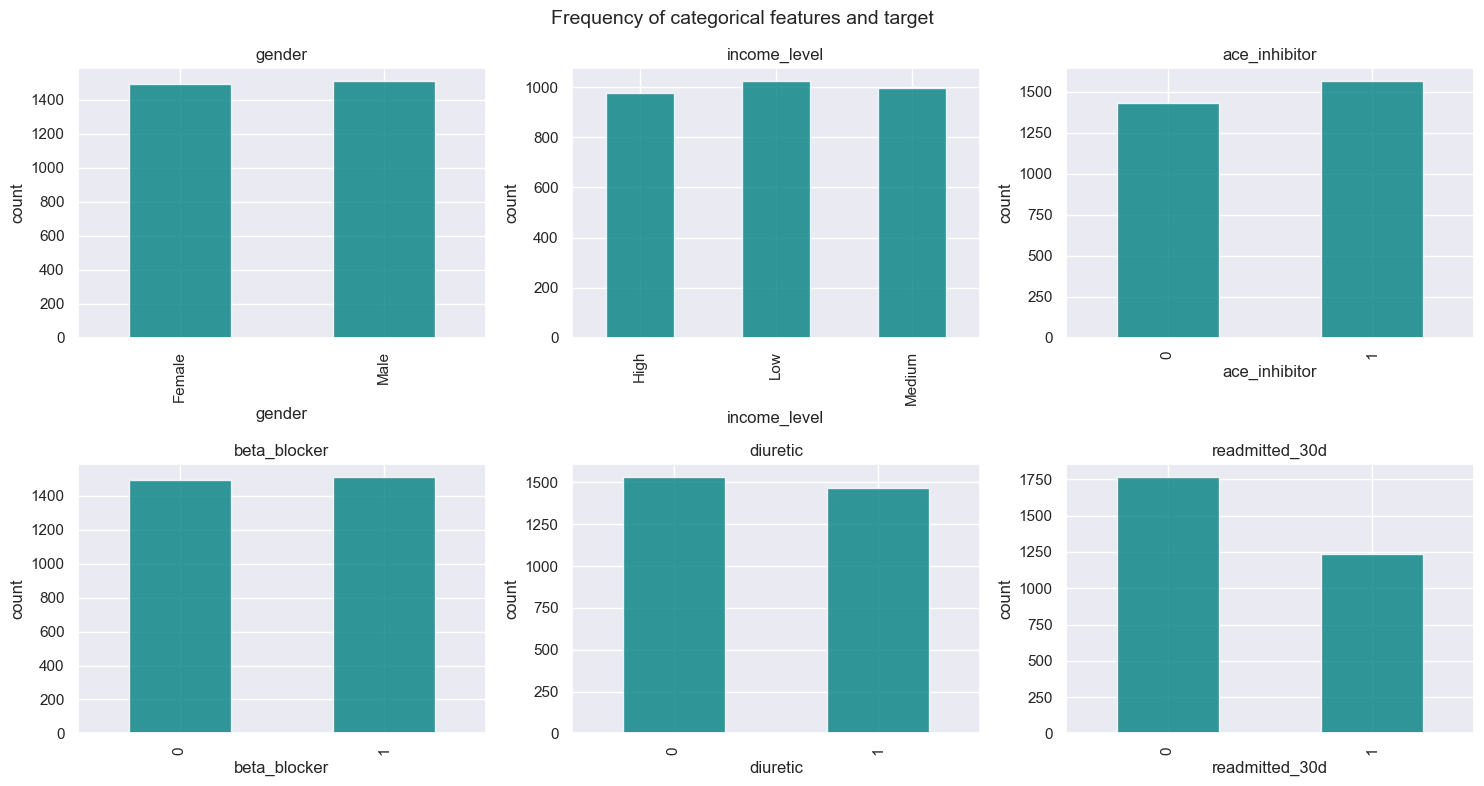

saved table : tbl_categorical_freq.csv


feature         level 
gender          Female    1492
                Male      1508
income_level    High       978
                Low       1024
                Medium     998
ace_inhibitor   0         1435
                1         1565
beta_blocker    0         1490
                1         1510
diuretic        0         1533
                1         1467
readmitted_30d  0         1766
                1         1234
Name: count, dtype: int64

In [7]:
# frequency of each categorical/binary feature and the target (Ch 1.4 - frequency distributions)
cat_cols = categorical + binary + [TARGET]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
freq_tables = {}
for ax, col in zip(axes.ravel(), cat_cols):
    counts = df[col].value_counts().sort_index()
    freq_tables[col] = counts
    counts.plot(kind='bar', ax=ax, color='teal', alpha=0.8)
    ax.set_title(col)
    ax.set_ylabel('count')
fig.suptitle('Frequency of categorical features and target', fontsize=14)
fig.tight_layout()
save_fig(fig, 'fig_bar_categorical.png')
plt.show()

# save the counts as one tidy table
freq_df = pd.concat(freq_tables, axis=0).rename('count')
freq_df.index.names = ['feature', 'level']
save_table(freq_df.to_frame(), 'tbl_categorical_freq.csv')
freq_df

## 3. Probability distributions (Ch 2)

Compare the shape of two features against named distributions: `sodium` looks roughly **normal**, while `bnp` is right-skewed and is better described by a **gamma** distribution. Then use **z-scores** (Ch 2.3) to check the empirical rule.

saved figure: fig_dist_normal_sodium.png


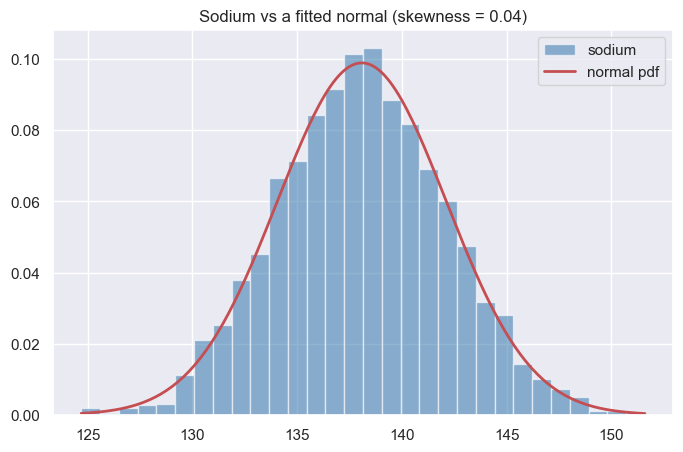

In [8]:
# sodium is roughly symmetric, so overlay a normal pdf with the sample mean and sd
x = df['sodium'].dropna()
mu, sd = x.mean(), x.std()
grid = np.linspace(x.min(), x.max(), 200)
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(x, bins=30, density=True, alpha=0.6, color='steelblue', label='sodium')
ax.plot(grid, stats.norm.pdf(grid, mu, sd), 'r-', linewidth=2, label='normal pdf')
ax.set_title(f'Sodium vs a fitted normal (skewness = {x.skew():.2f})')
ax.legend()
save_fig(fig, 'fig_dist_normal_sodium.png')
plt.show()

saved figure: fig_dist_gamma_bnp.png


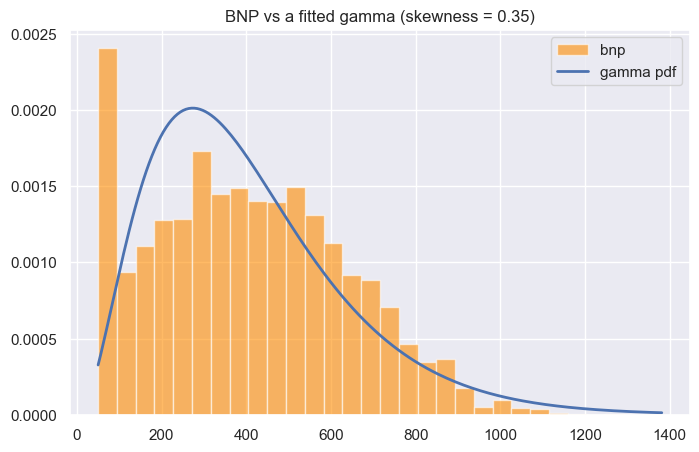

In [9]:
# bnp is right-skewed; fit a gamma by method of moments (same trick as the Ch 3 assignment)
x = df['bnp'].dropna()
mu, sd = x.mean(), x.std()
shape = (mu / sd) ** 2
scale = sd ** 2 / mu
grid = np.linspace(x.min(), x.max(), 200)
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(x, bins=30, density=True, alpha=0.6, color='darkorange', label='bnp')
ax.plot(grid, stats.gamma.pdf(grid, a=shape, scale=scale), 'b-', linewidth=2, label='gamma pdf')
ax.set_title(f'BNP vs a fitted gamma (skewness = {x.skew():.2f})')
ax.legend()
save_fig(fig, 'fig_dist_gamma_bnp.png')
plt.show()

In [10]:
# standardize age to z-scores and compare the empirical rule to normal theory (68/95/99.7)
z = (df['age'] - df['age'].mean()) / df['age'].std()
rows = []
for k in [1, 2, 3]:
    empirical = np.mean(np.abs(z) <= k)
    theoretical = stats.norm.cdf(k) - stats.norm.cdf(-k)
    rows.append({'within_k_sd': k, 'empirical': round(empirical, 3),
                 'normal_theory': round(theoretical, 3)})
empirical_rule = pd.DataFrame(rows).set_index('within_k_sd')
save_table(empirical_rule, 'tbl_empirical_rule_age.csv')
empirical_rule

saved table : tbl_empirical_rule_age.csv


,empirical,normal_theory
within_k_sd,,
1,0.575,0.683
2,1.000,0.954
3,1.000,0.997


## 4. Sampling distribution of the mean and the CLT (Ch 3)

Even though `bnp` is skewed, the distribution of the **sample mean** should look normal for a large enough sample, and its spread should match the standard error sigma/sqrt(n). We check this by simulation.

population mean        = 406.31
mean of sample means   = 406.11
theoretical SE (sd/sqrt(n)) = 36.73
observed SD of means        = 36.60


saved figure: fig_clt_bnp.png


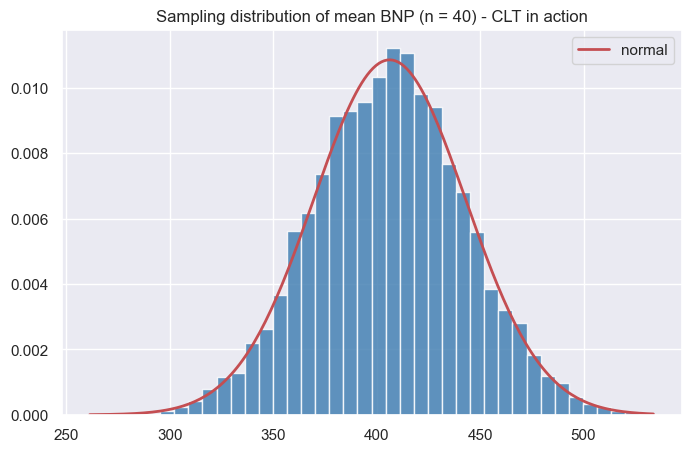

In [11]:
# draw many samples of size n from bnp and look at the distribution of their means
rng = np.random.default_rng(42)
bnp = df['bnp'].dropna().to_numpy()
n, num_samples = 40, 5000
sample_means = np.array([rng.choice(bnp, n, replace=True).mean() for _ in range(num_samples)])

theoretical_se = bnp.std(ddof=1) / np.sqrt(n)
print(f'population mean        = {bnp.mean():.2f}')
print(f'mean of sample means   = {sample_means.mean():.2f}')
print(f'theoretical SE (sd/sqrt(n)) = {theoretical_se:.2f}')
print(f'observed SD of means        = {sample_means.std(ddof=1):.2f}')

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(sample_means, bins=40, density=True, color='steelblue', edgecolor='white', alpha=0.85)
grid = np.linspace(sample_means.min(), sample_means.max(), 200)
ax.plot(grid, stats.norm.pdf(grid, bnp.mean(), theoretical_se), 'r-', linewidth=2, label='normal')
ax.set_title(f'Sampling distribution of mean BNP (n = {n}) - CLT in action')
ax.legend()
save_fig(fig, 'fig_clt_bnp.png')
plt.show()

## 5. Estimation — confidence intervals (Ch 4)

95% **t-based** confidence intervals for each numeric mean (Ch 4.4), a **Wald** interval for the readmission proportion (Ch 4.3), a **bootstrap** interval for the mean of skewed BNP (Ch 4.6), and a **Bayesian** posterior for the readmission proportion (Ch 4.7).

In [12]:
# 95% confidence interval for each numeric mean using the t distribution
rows = []
for col in numeric:
    x = df[col].dropna()
    mean, sem = x.mean(), stats.sem(x)
    lo, hi = stats.t.interval(0.95, len(x) - 1, loc=mean, scale=sem)
    rows.append({'feature': col, 'mean': mean, 'ci_low': lo, 'ci_high': hi})
mean_cis = pd.DataFrame(rows).set_index('feature').round(3)
save_table(mean_cis, 'tbl_mean_cis.csv')
mean_cis

saved table : tbl_mean_cis.csv


,mean,ci_low,ci_high
feature,,,
age,65.254,64.724,65.784
bmi,28.116,27.936,28.295
bnp,406.308,397.993,414.623
sodium,138.089,137.943,138.236
creatinine,1.204,1.186,1.221
systolic_bp,129.589,128.863,130.314
heart_rate,79.402,78.857,79.946
adherence_score,0.699,0.693,0.706
distance_to_hospital_km,25.400,24.893,25.906


In [13]:
# 95% Wald confidence interval for the readmission proportion (p +/- 1.96*sqrt(p(1-p)/n))
y = df[TARGET]
p_hat, n = y.mean(), len(y)
se = np.sqrt(p_hat * (1 - p_hat) / n)
print(f'readmission proportion = {p_hat:.4f}')
print(f'95% CI = ({p_hat - 1.96 * se:.4f}, {p_hat + 1.96 * se:.4f})')

readmission proportion = 0.4113
95% CI = (0.3937, 0.4289)


bootstrap 95% CI = (397.83, 414.52)
t-based   95% CI = (397.99, 414.62)  (should be very close)


saved figure: fig_bootstrap_bnp.png


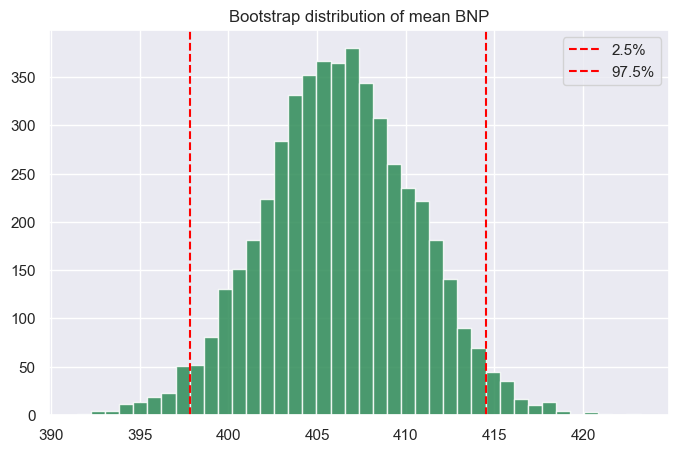

In [14]:
# bootstrap CI for the mean BNP: resample with replacement and take the middle 95%
rng = np.random.default_rng(0)
bnp = df['bnp'].dropna().to_numpy()
boot_means = np.array([rng.choice(bnp, len(bnp), replace=True).mean() for _ in range(5000)])
lo, hi = np.percentile(boot_means, [2.5, 97.5])
t_lo, t_hi = stats.t.interval(0.95, len(bnp) - 1, loc=bnp.mean(), scale=stats.sem(bnp))
print(f'bootstrap 95% CI = ({lo:.2f}, {hi:.2f})')
print(f't-based   95% CI = ({t_lo:.2f}, {t_hi:.2f})  (should be very close)')

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(boot_means, bins=40, color='seagreen', edgecolor='white', alpha=0.85)
ax.axvline(lo, color='red', linestyle='dashed', label='2.5%')
ax.axvline(hi, color='red', linestyle='dashed', label='97.5%')
ax.set_title('Bootstrap distribution of mean BNP')
ax.legend()
save_fig(fig, 'fig_bootstrap_bnp.png')
plt.show()

posterior mean = 0.4114
95% credible interval = (0.3938, 0.4290)


saved figure: fig_bayes_proportion.png


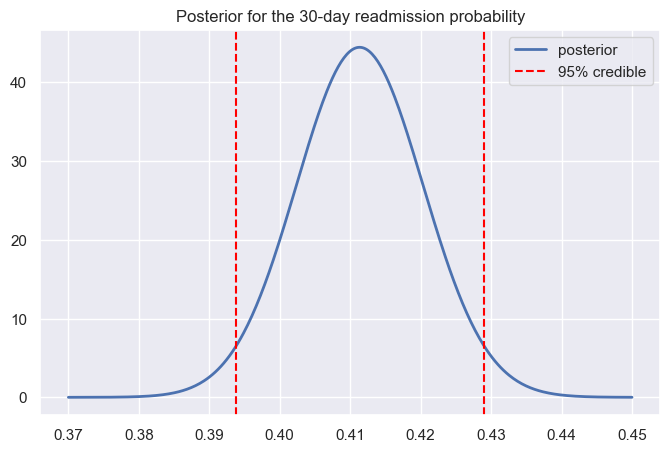

In [15]:
# Bayesian estimate of the readmission rate: flat Beta(1,1) prior -> Beta(1+s, 1+f) posterior
y = df[TARGET]
successes, failures = int(y.sum()), int((1 - y).sum())
a_post, b_post = 1 + successes, 1 + failures
cred_lo, cred_hi = stats.beta.ppf([0.025, 0.975], a_post, b_post)
print(f'posterior mean = {a_post / (a_post + b_post):.4f}')
print(f'95% credible interval = ({cred_lo:.4f}, {cred_hi:.4f})')

grid = np.linspace(0.37, 0.45, 400)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(grid, stats.beta.pdf(grid, a_post, b_post), 'b-', linewidth=2, label='posterior')
ax.axvline(cred_lo, color='red', linestyle='dashed')
ax.axvline(cred_hi, color='red', linestyle='dashed', label='95% credible')
ax.set_title('Posterior for the 30-day readmission probability')
ax.legend()
save_fig(fig, 'fig_bayes_proportion.png')
plt.show()

## 6. Bivariate analysis and significance testing (Ch 1.5, Ch 5)

How does each predictor relate to readmission? Correlations between numeric features, a regression line for one pair, then formal tests: Welch's t-test with **effect size and a CI for the difference** (Ch 4.5, 5.3) for numeric predictors, and chi-square with **Cramér's V** (Ch 5.4) for categorical ones. A permutation test (Ch 5.8) and a power calculation (Ch 5.5) round it out.

*Note: formal multiple-testing correction is applied in `03_statistical_testing`; here we report raw p-values alongside effect sizes to weigh statistical vs practical significance (Ch 5.6).*

saved table : tbl_correlations.csv


saved figure: fig_corr_heatmap.png


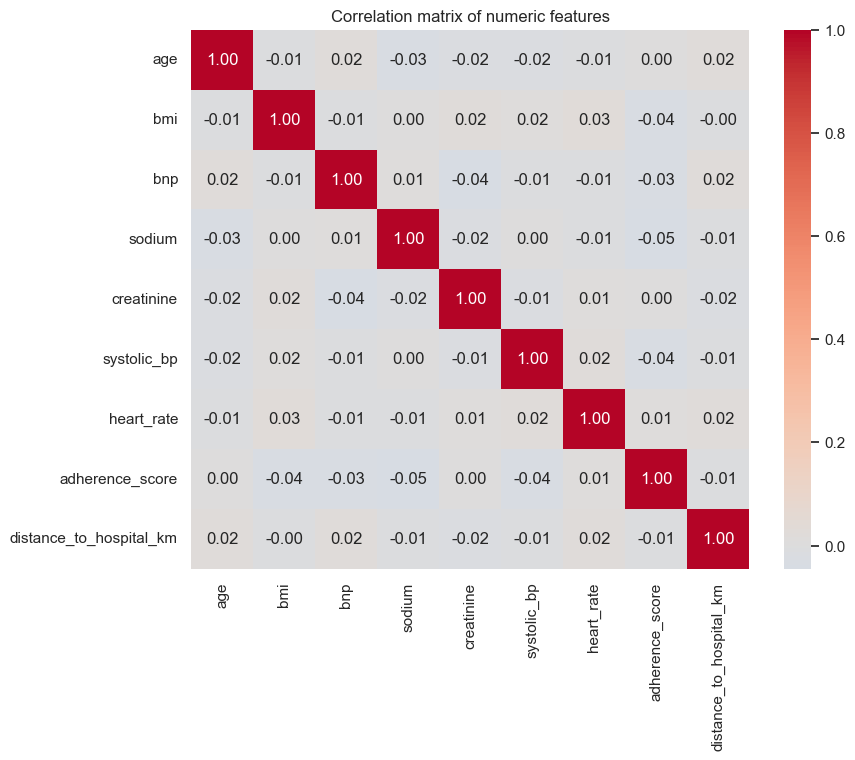

In [16]:
# Pearson correlations among the numeric features (Ch 1.5, Ch 2.7)
corr = df[numeric].corr()
save_table(corr.round(3), 'tbl_correlations.csv')
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation matrix of numeric features')
save_fig(fig, 'fig_corr_heatmap.png')
plt.show()

saved figure: fig_scatter_reg.png


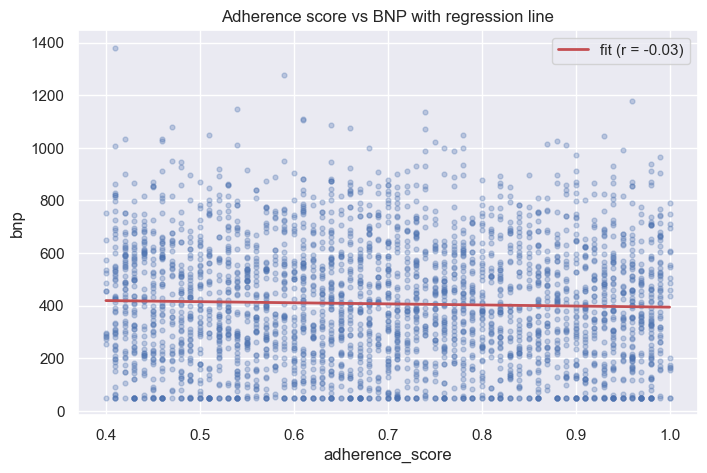

In [17]:
# scatterplot with a least-squares regression line (Ch 1.5) for the two strongest numeric signals
x, yv = df['adherence_score'], df['bnp']
slope, intercept = np.polyfit(x, yv, 1)
r = np.corrcoef(x, yv)[0, 1]
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x, yv, alpha=0.3, s=12)
grid = np.linspace(x.min(), x.max(), 100)
ax.plot(grid, slope * grid + intercept, 'r-', linewidth=2, label=f'fit (r = {r:.2f})')
ax.set_xlabel('adherence_score')
ax.set_ylabel('bnp')
ax.set_title('Adherence score vs BNP with regression line')
ax.legend()
save_fig(fig, 'fig_scatter_reg.png')
plt.show()

/tmp/claude-501/ipykernel_2572/760059258.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=['not readm.', 'readmitted'])
/tmp/claude-501/ipykernel_2572/760059258.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=['not readm.', 'readmitted'])
/tmp/claude-501/ipykernel_2572/760059258.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=['not readm.', 'readmitted'])
/tmp/claude-501/ipykernel_2572/760059258.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for 

saved figure: fig_box_by_target.png


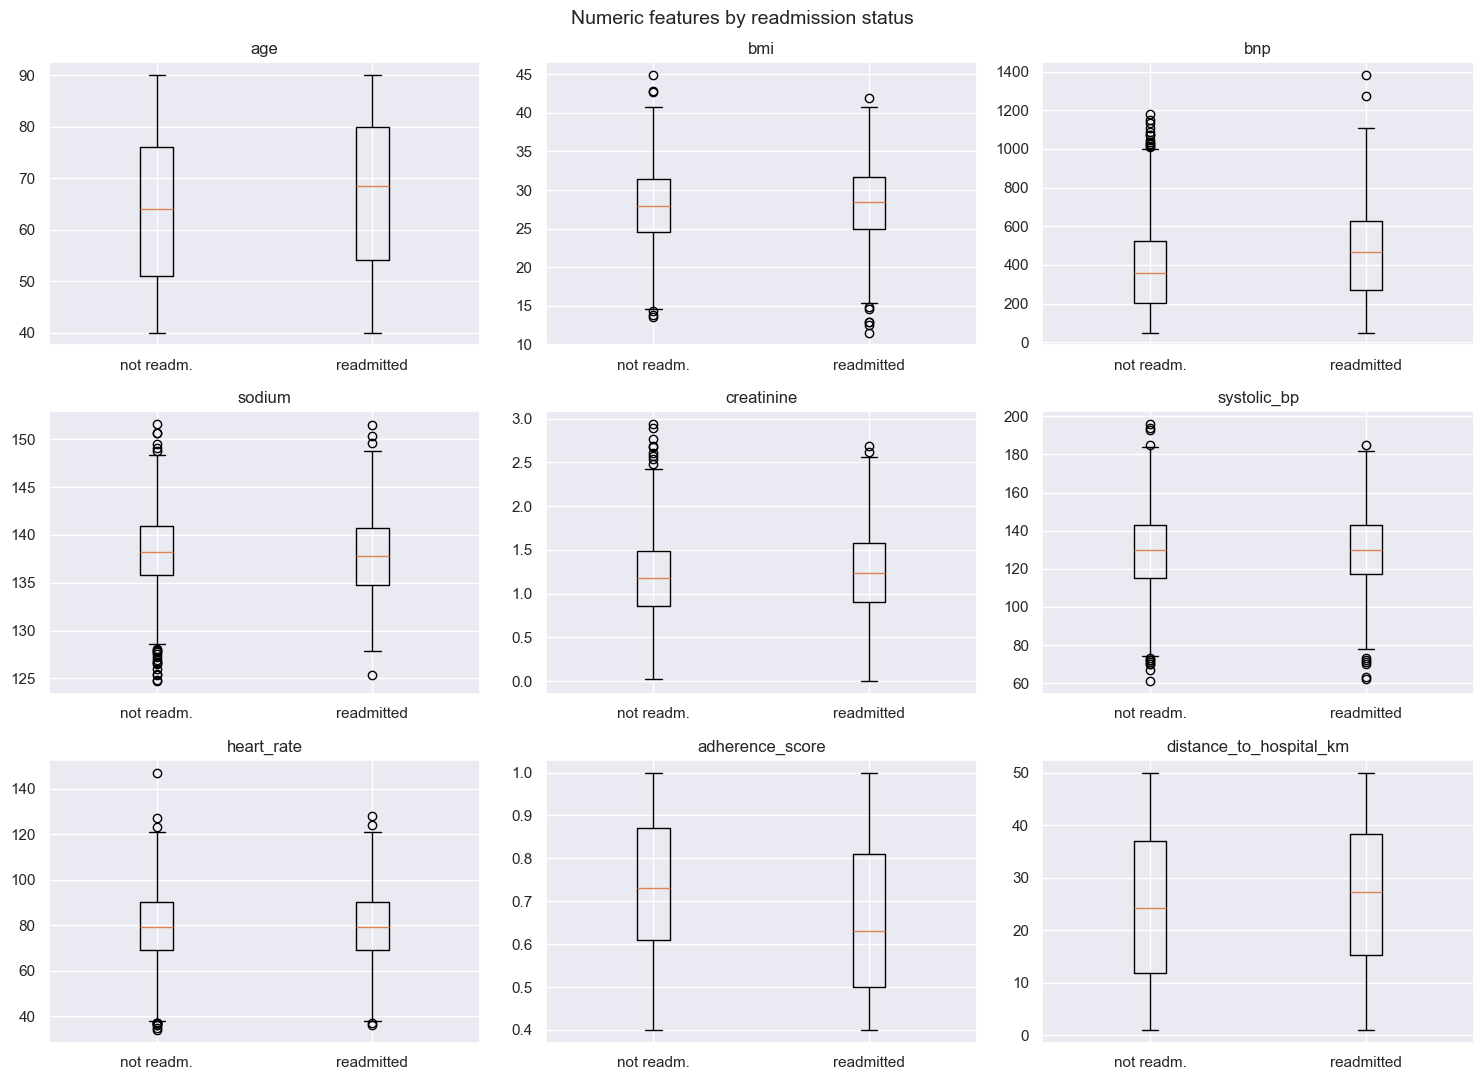

In [18]:
# do the numeric features separate the two readmission groups? (box plots by target)
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
for ax, col in zip(axes.ravel(), numeric):
    groups = [df.loc[df[TARGET] == g, col].dropna() for g in (0, 1)]
    ax.boxplot(groups, labels=['not readm.', 'readmitted'])
    ax.set_title(col)
fig.suptitle('Numeric features by readmission status', fontsize=14)
fig.tight_layout()
save_fig(fig, 'fig_box_by_target.png')
plt.show()

In [19]:
# Welch t-test + Cohen's d + 95% CI for the difference in means, for each numeric feature
def cohens_d(a, b):
    n1, n2 = len(a), len(b)
    sp = np.sqrt(((n1 - 1) * a.var(ddof=1) + (n2 - 1) * b.var(ddof=1)) / (n1 + n2 - 2))
    return (b.mean() - a.mean()) / sp

rows = []
for col in numeric:
    a = df.loc[df[TARGET] == 0, col].dropna()
    b = df.loc[df[TARGET] == 1, col].dropna()
    t, p = stats.ttest_ind(a, b, equal_var=False)
    v1, v2, n1, n2 = a.var(ddof=1), b.var(ddof=1), len(a), len(b)
    se = np.sqrt(v1 / n1 + v2 / n2)
    dfree = (v1 / n1 + v2 / n2) ** 2 / ((v1 / n1) ** 2 / (n1 - 1) + (v2 / n2) ** 2 / (n2 - 1))
    tcrit = stats.t.ppf(0.975, dfree)
    diff = b.mean() - a.mean()
    rows.append({'feature': col, 'mean_not': a.mean(), 'mean_readm': b.mean(),
                 'diff': diff, 'diff_ci_low': diff - tcrit * se, 'diff_ci_high': diff + tcrit * se,
                 'cohens_d': cohens_d(a, b), 'p_value': p})
numeric_tests = pd.DataFrame(rows).set_index('feature')
numeric_tests = numeric_tests.reindex(numeric_tests['cohens_d'].abs().sort_values(ascending=False).index)
save_table(numeric_tests.round(4), 'tbl_numeric_vs_target.csv')
numeric_tests.round(4)

saved table : tbl_numeric_vs_target.csv


,mean_not,mean_readm,diff,diff_ci_low,diff_ci_high,cohens_d,p_value
feature,,,,,,,
adherence_score,0.7274,0.6593,-0.0681,-0.0806,-0.0556,-0.4012,0.0000
bnp,374.9881,451.1305,76.1424,59.2901,92.9946,0.3321,0.0000
age,64.1217,66.8752,2.7535,1.6787,3.8282,0.1867,0.0000
distance_to_hospital_km,24.6071,26.5335,1.9264,0.9051,2.9477,0.1365,0.0002
sodium,138.2624,137.8431,-0.4193,-0.7199,-0.1187,-0.1041,0.0063
creatinine,1.1853,1.2299,0.0446,0.0090,0.0803,0.0932,0.0142
systolic_bp,128.9949,130.4384,1.4435,-0.0160,2.9030,0.0713,0.0526
bmi,28.0033,28.2764,0.2730,-0.0918,0.6378,0.0553,0.1424
heart_rate,79.5575,79.1792,-0.3783,-1.4850,0.7285,-0.0249,0.5028


In [20]:
# chi-square test of independence + Cramer's V (effect size) for each categorical/binary feature
rows = []
for col in categorical + binary:
    table = pd.crosstab(df[col], df[TARGET])
    chi2, p, dof, _ = stats.chi2_contingency(table)
    n = table.to_numpy().sum()
    cramers_v = np.sqrt(chi2 / (n * (min(table.shape) - 1)))
    rows.append({'feature': col, 'chi2': chi2, 'dof': dof, 'p_value': p, 'cramers_v': cramers_v})
categorical_tests = pd.DataFrame(rows).set_index('feature').sort_values('p_value').round(4)
save_table(categorical_tests, 'tbl_categorical_vs_target.csv')
categorical_tests

saved table : tbl_categorical_vs_target.csv


,chi2,dof,p_value,cramers_v
feature,,,,
ace_inhibitor,25.6878,1,0.0000,0.0925
beta_blocker,21.5888,1,0.0000,0.0848
diuretic,0.6756,1,0.4111,0.0150
income_level,0.4509,2,0.7982,0.0123
gender,0.0002,1,0.9876,0.0003


In [21]:
# standardized residuals show WHICH cells drive a chi-square association (Ch 5.4)
table = pd.crosstab(df['ace_inhibitor'], df[TARGET])
chi2, p, dof, expected = stats.chi2_contingency(table)
std_resid = ((table - expected) / np.sqrt(expected)).round(2)
save_table(std_resid, 'tbl_std_residuals_ace.csv')
print('ace_inhibitor vs readmission - standardized residuals:')
std_resid

saved table : tbl_std_residuals_ace.csv
ace_inhibitor vs readmission - standardized residuals:


readmitted_30d,0,1
ace_inhibitor,,
0,-2.36,2.83
1,2.26,-2.71


observed difference in means = -0.0681
permutation p-value          = 0.0000
saved figure: fig_perm_adherence.png


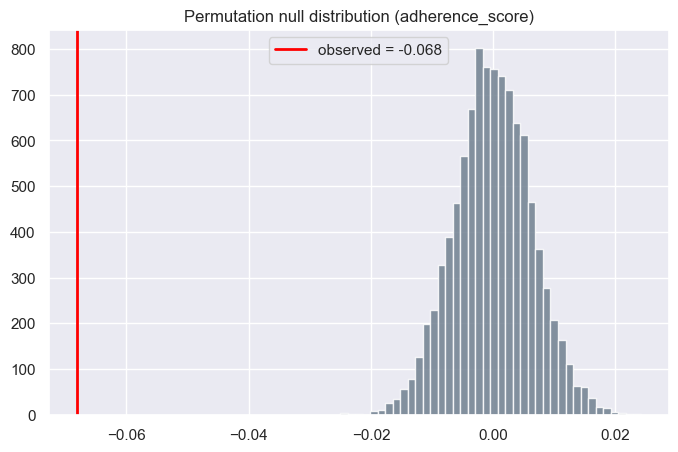

In [22]:
# permutation test for adherence_score: shuffle the labels many times to build the null (Ch 5.8)
rng = np.random.default_rng(7)
vals = df['adherence_score'].to_numpy()
labels = df[TARGET].to_numpy()
obs_diff = vals[labels == 1].mean() - vals[labels == 0].mean()
perm_diffs = np.empty(10000)
for i in range(perm_diffs.size):
    shuffled = rng.permutation(labels)
    perm_diffs[i] = vals[shuffled == 1].mean() - vals[shuffled == 0].mean()
p_perm = np.mean(np.abs(perm_diffs) >= abs(obs_diff))
print(f'observed difference in means = {obs_diff:.4f}')
print(f'permutation p-value          = {p_perm:.4f}')

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(perm_diffs, bins=40, color='slategray', edgecolor='white', alpha=0.85)
ax.axvline(obs_diff, color='red', linewidth=2, label=f'observed = {obs_diff:.3f}')
ax.set_title('Permutation null distribution (adherence_score)')
ax.legend()
save_fig(fig, 'fig_perm_adherence.png')
plt.show()

In [23]:
# how much power did we have to detect the adherence_score effect? (Ch 5.5)
from statsmodels.stats.power import TTestIndPower
a = df.loc[df[TARGET] == 0, 'adherence_score'].dropna()
b = df.loc[df[TARGET] == 1, 'adherence_score'].dropna()
sp = np.sqrt(((len(a) - 1) * a.var(ddof=1) + (len(b) - 1) * b.var(ddof=1)) / (len(a) + len(b) - 2))
d = abs((b.mean() - a.mean()) / sp)
power = TTestIndPower().power(effect_size=d, nobs1=len(a), ratio=len(b) / len(a), alpha=0.05)
print(f"Cohen's d = {d:.3f}")
print(f'power at alpha=0.05 = {power:.3f}')

Cohen's d = 0.401
power at alpha=0.05 = 1.000


## 7. Summary of findings

One table ranking every predictor by its association with readmission, combining the numeric and categorical results above. This is the EDA headline that feeds the modeling notebook and the report.

In [24]:
# combine the numeric (Cohen's d) and categorical (Cramer's V) results into one ranked table
num = numeric_tests[['p_value']].copy()
num['effect_size'] = numeric_tests['cohens_d'].abs()
num['effect_type'] = "|Cohen's d|"
cat = categorical_tests[['p_value']].copy()
cat['effect_size'] = categorical_tests['cramers_v']
cat['effect_type'] = "Cramer's V"
findings = pd.concat([num, cat])
findings['significant_0_05'] = findings['p_value'] < 0.05
findings = findings.sort_values('effect_size', ascending=False).round(4)
save_table(findings, 'tbl_eda_findings.csv')
findings

saved table : tbl_eda_findings.csv


,p_value,effect_size,effect_type,significant_0_05
feature,,,,
adherence_score,0.0000,0.4012,|Cohen's d|,True
bnp,0.0000,0.3321,|Cohen's d|,True
age,0.0000,0.1867,|Cohen's d|,True
distance_to_hospital_km,0.0002,0.1365,|Cohen's d|,True
sodium,0.0063,0.1041,|Cohen's d|,True
creatinine,0.0142,0.0932,|Cohen's d|,True
ace_inhibitor,0.0000,0.0925,Cramer's V,True
beta_blocker,0.0000,0.0848,Cramer's V,True
systolic_bp,0.0526,0.0713,|Cohen's d|,False


## Notes

- The strongest signals are `adherence_score` and `bnp`, then `age`, `ace_inhibitor`, `beta_blocker`, and `distance_to_hospital_km` — consistent with the formal tests in notebook 03.
- Effect sizes are small-to-moderate, so even the 'significant' predictors explain little on their own; this matches the modest logistic-regression fit in notebook 04 (Ch 5.6 — statistical vs practical significance).
- `gender` and `income_level` show no association with readmission.
- All figures and tables are saved under `reports/figures/` and `reports/tables/`.